In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [18]:
# List of 10 companies with the Yahoo Finance suffix for Pakistan
symbols = ["MEBL.KA", "EFERT.KA", "SYS.KA", "LUCK.KA", "HUBC.KA", "OGDC.KA", "MTL.KA", "SEARL.KA", "ILP.KA", "NESTLE.KA"]

# Download all data
data = yf.download(symbols, start="2020-01-01", end="2025-12-31", auto_adjust=True)

[*********************100%***********************]  10 of 10 completed


In [3]:
data.head()

Price           Close                                               \
Ticker       EFERT.KA    HUBC.KA     ILP.KA     LUCK.KA    MEBL.KA   
Date                                                                 
2020-01-01  27.419878  33.049335  25.666683  428.987915  39.624851   
2020-01-02  27.475567  34.699490  25.867298  450.428467  40.134922   
2020-01-03  27.312220  34.987560  25.719019  454.983551  39.723568   
2020-01-06  26.966970  33.917095  25.160765  436.969177  39.180588   
2020-01-07  27.312220  34.493225  24.781324  457.496735  39.505558   

Price                                                                  ...  \
Ticker          MTL.KA    NESTLE.KA    OGDC.KA    SEARL.KA     SYS.KA  ...   
Date                                                                   ...   
2020-01-01  113.959824  6028.780762  87.915138  106.573021  55.491409  ...   
2020-01-02  114.610664  6178.564941  90.523308  110.111298  55.672794  ...   
2020-01-03  114.594559  6122.395996  91.950424  107.445168  54.407501  ...   
2020-01-06  112.297356  6122.395996  91.384483  102.112930  52.770592  ...   
2020-01-07  114.977959  5991.333984  91.661293  104.365059  52.761745  ...   

Price          Volume                                                        \
Ticker       EFERT.KA    HUBC.KA     ILP.KA    LUCK.KA    MEBL.KA    MTL.KA   
Date                                                                          
2020-01-01  1039500.0   555500.0   899808.0   461600.0   160718.0   48114.0   
2020-01-02  3035000.0  7051000.0  1465401.0   949200.0  1019969.0  155119.0   
2020-01-03  2232000.0  5327000.0   641916.0  1472500.0   336743.0  241724.0   
2020-01-06  1577500.0  2070000.0   314932.0  1079700.0   433452.0  178021.0   
2020-01-07  2328500.0  2076500.0   516586.0  1240100.0   715231.0  138375.0   

Price                                                 
Ticker     NESTLE.KA    OGDC.KA   SEARL.KA    SYS.KA  
Date                                                  
2020-01-01         0   784400.0  1415644.0  210760.0  
2020-01-02        40  4383500.0  3795610.0  245520.0  
2020-01-03        80  4019800.0  1545996.0  146520.0  
2020-01-06         0  3992300.0  1695795.0  238920.0  
2020-01-07       660  2355100.0  1202422.0  915860.0  

[5 rows x 50 columns]

In [4]:
data.columns

MultiIndex([( 'Close',  'EFERT.KA'),
            ( 'Close',   'HUBC.KA'),
            ( 'Close',    'ILP.KA'),
            ( 'Close',   'LUCK.KA'),
            ( 'Close',   'MEBL.KA'),
            ( 'Close',    'MTL.KA'),
            ( 'Close', 'NESTLE.KA'),
            ( 'Close',   'OGDC.KA'),
            ( 'Close',  'SEARL.KA'),
            ( 'Close',    'SYS.KA'),
            (  'High',  'EFERT.KA'),
            (  'High',   'HUBC.KA'),
            (  'High',    'ILP.KA'),
            (  'High',   'LUCK.KA'),
            (  'High',   'MEBL.KA'),
            (  'High',    'MTL.KA'),
            (  'High', 'NESTLE.KA'),
            (  'High',   'OGDC.KA'),
            (  'High',  'SEARL.KA'),
            (  'High',    'SYS.KA'),
            (   'Low',  'EFERT.KA'),
            (   'Low',   'HUBC.KA'),
            (   'Low',    'ILP.KA'),
            (   'Low',   'LUCK.KA'),
            (   'Low',   'MEBL.KA'),
            (   'Low',    'MTL.KA'),
            (   'Low', 'NESTLE.KA'),
 

In [5]:
# Remove duplicated rows
data = data.drop_duplicates()

# Fill NaNs (Forward fill is standard for finance to use the last known price)
data = data.ffill()

In [6]:
# Calculate return of all tickers under 'Close'
daily_returns = data["Close"].pct_change()

In [7]:
daily_returns.head()

Ticker,EFERT.KA,HUBC.KA,ILP.KA,LUCK.KA,MEBL.KA,MTL.KA,NESTLE.KA,OGDC.KA,SEARL.KA,SYS.KA
Date,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,0.002031,0.049930,0.007816,0.049979,0.012872,0.005711,0.024845,0.029667,0.033200,0.003269
2020-01-03,-0.005945,0.008302,-0.005732,0.010113,-0.010249,-0.000141,-0.009091,0.015765,-0.024213,-0.022727
2020-01-06,-0.012641,-0.030596,-0.021706,-0.039593,-0.013669,-0.020046,0.000000,-0.006155,-0.049628,-0.030086
2020-01-07,0.012803,0.016986,-0.015081,0.046977,0.008294,0.023871,-0.021407,0.003029,0.022055,-0.000168


In [8]:
# 50-Days Moving Avrage of all tickers
ma50 = data["Close"].rolling(window=50).mean()

# 200-Days Moving Avrage of all tickers
ma200 = data["Close"].rolling(window=200).mean()

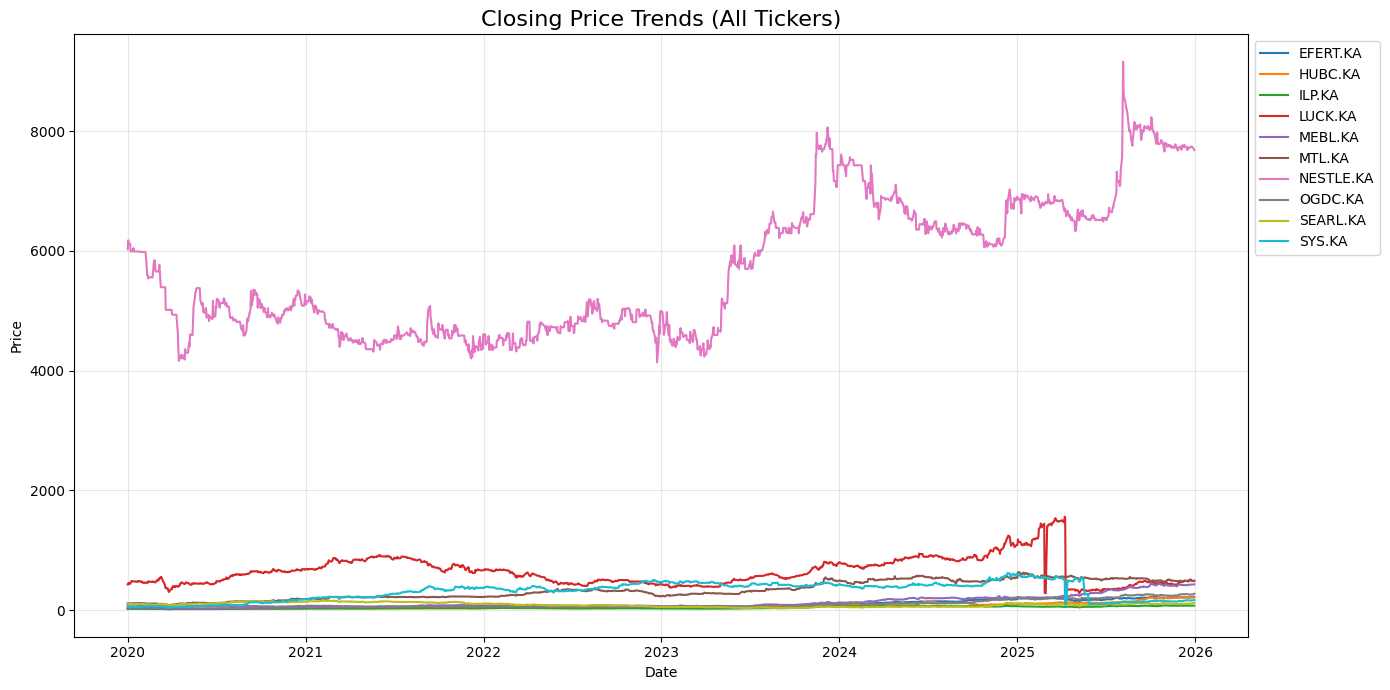

In [9]:
# Isolate the 'Close' prices
df_close = data["Close"]

# Ploting
plt.figure(figsize=(14, 7))
plt.plot(df_close)

# Formating the chart
plt.title("Closing Price Trends (All Tickers)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(df_close.columns, bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

##Price Trend Observations
* **Scale Disparity:** The initial plot of closing prices reveals a massive variance in nominal pricing across the portfolio. **NESTLE.KA** trades at an entirely different scale (fluctuating between PKR 4,000 and PKR 9,000), which visually flattens the price action of lower-priced equities like **EFERT.KA** (PKR ~27) and **SYS.KA**.
* **Trend Distortions:** Because of this scale distortion, a percentage-based normalization (indexing all assets to a base of 100) or individual subplots are required to accurately evaluate short-term volatility and moving average crossovers for individual stocks.

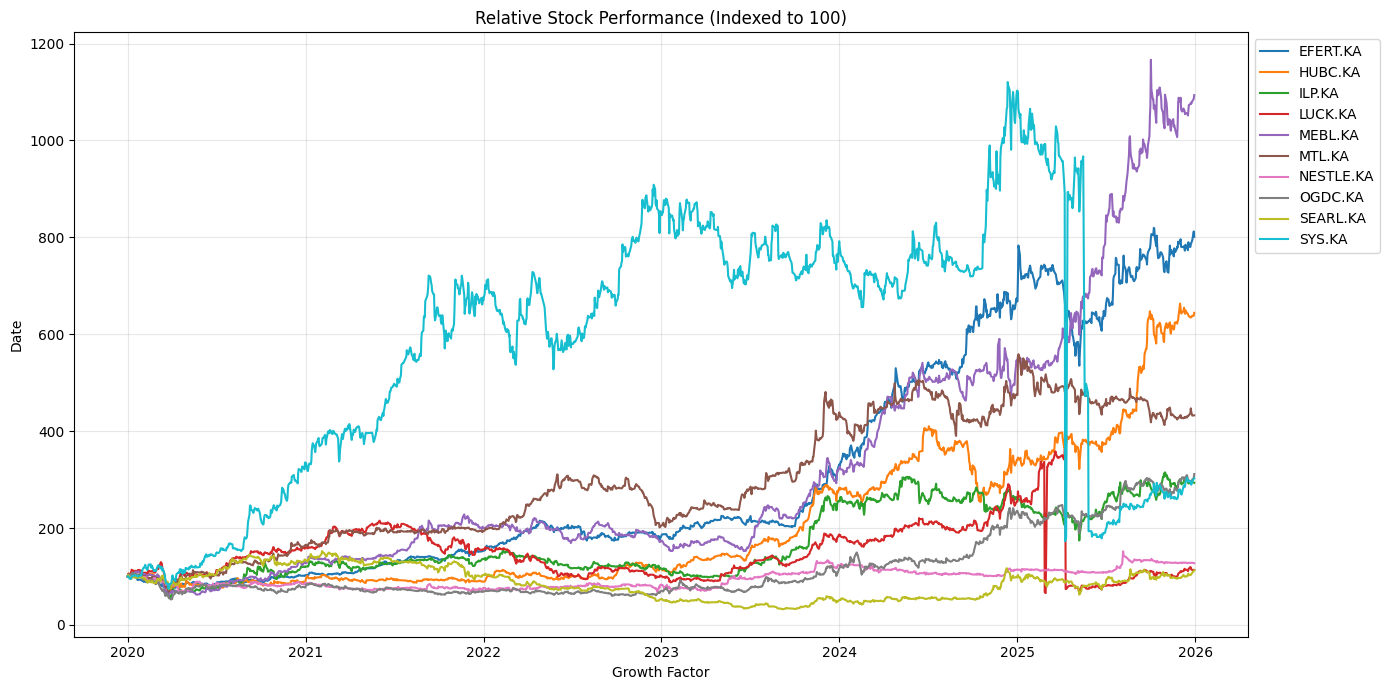

In [10]:
# Normalize: (Price / Price at Start) * 100
normalized_data = df_close / df_close.iloc[0] * 100

plt.figure(figsize=(14, 7))
plt.plot(normalized_data)

plt.title("Relative Stock Performance (Indexed to 100)")
plt.xlabel("Growth Factor")
plt.ylabel("Date")
plt.legend(normalized_data.columns, bbox_to_anchor=(1, 1))
plt.grid(True, alpha=(0.3))
plt.tight_layout()
plt.show()

#**Correlation Analysis**

In [11]:
# Look at existing data's start and end dates
start_date = data.index.min()
end_date = data.index.max()

# Download the external Micro Data from Yahoo Fiance
# 'PKR=X' is the USD to PKR currency pair
macro_data = yf.download(["PKR=X"], start=start_date, end=end_date, auto_adjust=True)["Close"]

[*********************100%***********************]  1 of 1 completed


In [12]:
macro_data.head()

Ticker,PKR=X
Date,
2020-01-01,154.550003
2020-01-02,154.227737
2020-01-03,154.000000
2020-01-06,154.449997
2020-01-07,154.600006


In [14]:
# Create a Clean, flat copy of existing stock 'Close' Prices
df_analysis = data["Close"].copy()

# Merage the downloaded macro data into analysis DataFrame
df_analysis["USD_PKR"] = macro_data["PKR=X"]

In [15]:
# Handle any missing data
df_analysis = df_analysis.ffill().dropna()

In [16]:
# Calculate Correlation matrix
corr_matrix = df_analysis.corr()

## Summary Matrix Table

| Asset Pair | Correlation Coefficient | Portfolio Classification | Economic Driver |
| :--- | :--- | :--- | :--- |
| **SYS.KA / USD_PKR** | **0.53** | Macro Hedge | Dollar-denominated export revenue expansion. |
| **SYS.KA / MEBL.KA** | **0.03** | Pure Diversifier | Independent structural drivers distinct from local banking cycles. |
| **SEARL.KA / USD_PKR** | **-0.74** | Vulnerable Asset | Import-dependent raw materials squeezed by currency devaluation. |
| **HUBC.KA / MEBL.KA** | **0.96** | Core Index Mover | Interconnected systemic performance within the domestic economy. |

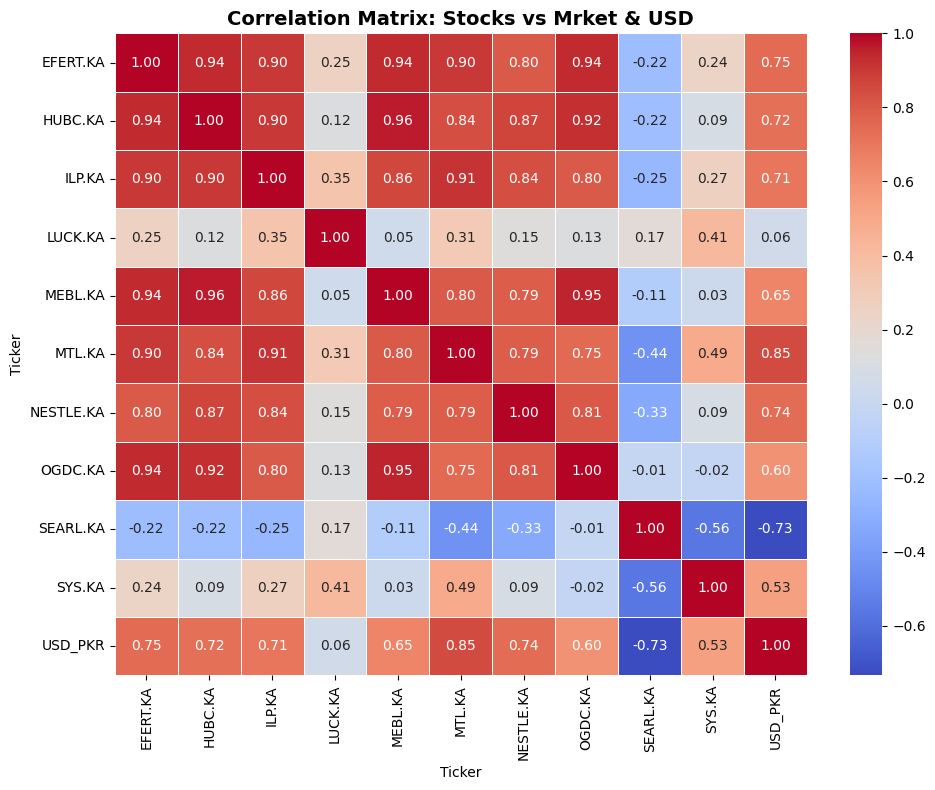

In [17]:
plt.figure(figsize=(10, 8))

# 'coolwarm' maps negative correlations to blue, 0 to white, and positive to red
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Matrix: Stocks vs Mrket & USD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()